In [1]:
import torch
import matplotlib.pyplot as plt
from torch import optim, distributions, nn
from tqdm.notebook import tqdm
import gpzoo
from gpzoo.kernels import NSF_RBF, batched_RBF, batched_MGGP_Matern32
from gpzoo.gp import GaussianPrior, SVGP, MGGP_VNNGP, MGGP_WSVGP
from gpzoo.likelihoods import PNMF, NSF2, Hybrid_NSF2, Hybrid_NSF_Exact
from gpzoo.utilities import init_Lu, whitened_KL, train_hybrid, train_hybrid_batched, anndata_to_train_val, rescale_spatial_coords, add_jitter, scanpy_sizefactors, init_softplus
import squidpy as sq
import numpy as np
from sklearn.decomposition import NMF
import scanpy as sc
import random

from gpzoo.utilities import regularized_nmf, dims_autocorr
from matplotlib.animation import FuncAnimation
from matplotlib import animation
import pickle
from sklearn.cluster import KMeans

import matplotlib.patheffects as path_effects

import pandas as pd

import anndata as ad
import gc
import umap

/gladstone/engelhardt/home/lchumpitaz/gitclones/GPzoo/gpzoo/utilities.py:2: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm
/gladstone/engelhardt/home/lchumpitaz/miniconda3/envs/gpzoo/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/gladstone/engelhardt/home/lchumpitaz/miniconda3/envs/gpzoo/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to 

In [2]:
def plot_factors(factors, X, moran_idx=None, ax=None, size=7, alpha=0.8, s=0.1, names=None, vmin=None, vmax=None, cmap='turbo'):
    # If vmin/vmax not provided, infer from percentiles
    if vmin is None:
        vmin = np.percentile(factors, 1)
    if vmax is None:
        vmax = np.percentile(factors, 99)

    if moran_idx is not None:
        factors = factors[moran_idx]
        if names is not None:
            names = names[moran_idx]

    L = len(factors)

    if ax is None:
        fig, ax = plt.subplots(2, 6, figsize=(size*6, size*2), tight_layout=True, subplot_kw={'projection': '3d'})

    for i in range(L):
        curr_ax = ax[i // 6, i % 6]

        curr_ax.scatter(
            X[:, 0], X[:, 1], X[:,2],
            c=factors[i],
            vmin=vmin,
            vmax=vmax,
            alpha=alpha,
            cmap=cmap,
            s=s
        )

        # curr_ax.invert_yaxis()

        if names is not None:
            curr_ax.set_title(
                names[i],
                x=0.03, y=0.88,
                fontsize="small",
                color="white",
                ha="left", va="top"
            )

        curr_ax.set_xticks([])
        curr_ax.set_yticks([])
        curr_ax.set_facecolor('xkcd:gray')


In [3]:
adata = sq.datasets.merfish()
adata

AnnData object with n_obs × n_vars = 73655 × 161
    obs: 'Cell_ID', 'Animal_ID', 'Animal_sex', 'Behavior', 'Bregma', 'Centroid_X', 'Centroid_Y', 'Cell_class', 'Neuron_cluster_ID', 'batch'
    uns: 'Cell_class_colors'
    obsm: 'spatial', 'spatial3d'

In [4]:
adata

AnnData object with n_obs × n_vars = 73655 × 161
    obs: 'Cell_ID', 'Animal_ID', 'Animal_sex', 'Behavior', 'Bregma', 'Centroid_X', 'Centroid_Y', 'Cell_class', 'Neuron_cluster_ID', 'batch'
    uns: 'Cell_class_colors'
    obsm: 'spatial', 'spatial3d'

In [5]:
X = adata.obsm['spatial3d']
X[:, 2] = X[:, 2]/50.0
X = X*50.0

In [6]:
len(X)

73655

In [7]:
adata.uns['Cell_class_colors']

array(['#1f77b4', '#ff7f0e', '#279e68', '#d62728', '#aa40fc', '#8c564b',
       '#e377c2', '#b5bd61', '#17becf', '#aec7e8', '#ffbb78', '#98df8a',
       '#ff9896', '#c5b0d5', '#c49c94', '#f7b6d2'], dtype=object)

/tmp/ipykernel_1808858/580182118.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.scatter(X[idx][:, 0], X[idx][:, 1], X[idx][:, 2], s=0.1, label=class_label, color=color)


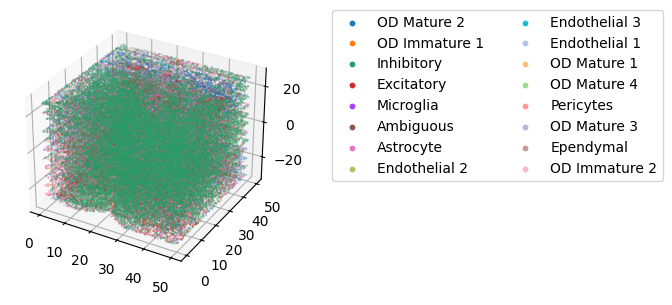

In [21]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')



for class_label, color in zip(adata.obs.Cell_class.unique(), adata.uns['Cell_class_colors']):
    idx = adata.obs.Cell_class == class_label
    ax.scatter(X[idx][:, 0], X[idx][:, 1], X[idx][:, 2], s=0.1, label=class_label, color=color)

# ax.invert_yaxis()

ax.legend(
    bbox_to_anchor=(1.2, 1),
    loc='upper left',
    borderaxespad=0.,
    ncol=(len(adata.obs.Cell_class.unique()) + 9) // 10,
    markerscale=10  # <-- Increase this to make legend markers larger
)

plt.tight_layout()
plt.show()

In [22]:
adata.X.T

<Compressed Sparse Column sparse matrix of dtype 'float32'
	with 4660375 stored elements and shape (161, 73655)>

In [23]:
Y = adata.X.T.toarray()
V = scanpy_sizefactors(Y.T)

In [24]:
trans = umap.UMAP(n_neighbors=5, min_dist=0.0, random_state=12).fit(X=Y.T, )

/gladstone/engelhardt/home/lchumpitaz/miniconda3/envs/gpzoo/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


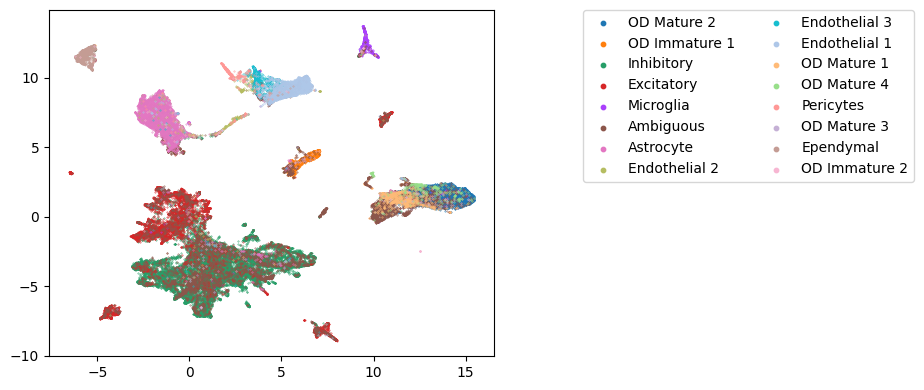

In [25]:
fig = plt.figure(figsize=(10, 4))
ax = fig.add_subplot()



for class_label, color in zip(adata.obs.Cell_class.unique(), adata.uns['Cell_class_colors']):
    idx = adata.obs.Cell_class == class_label
    ax.scatter(trans.embedding_[idx][:, 0], trans.embedding_[idx][:, 1], s=0.1, label=class_label, color=color)

# ax.invert_yaxis()

ax.legend(
    bbox_to_anchor=(1.2, 1),
    loc='upper left',
    borderaxespad=0.,
    ncol=(len(adata.obs.Cell_class.unique()) + 9) // 10,
    markerscale=10  # <-- Increase this to make legend markers larger
)

plt.tight_layout()
plt.show()

In [26]:
X = torch.tensor(X).type(torch.float)
Y = torch.tensor(Y).type(torch.float)
groupsX = torch.tensor(adata.obs.Cell_class.values.codes).type(torch.LongTensor)
n_groups = len(adata.obs.Cell_class.values.categories)



/tmp/ipykernel_1808858/2094919376.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X).type(torch.float)


In [27]:
avg_cell_type_distances = np.array([np.mean(trans.embedding_[groupsX==i], axis=0)  for i in torch.unique(groupsX)])
avg_cell_type_distances = torch.tensor(avg_cell_type_distances)

In [28]:
cell_type_dist_matrix = torch.cdist(avg_cell_type_distances, avg_cell_type_distances)

In [29]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda', index=0)

In [30]:
D, N = Y.shape

In [31]:
len(X)//20

3682

In [32]:
M = N
L = 12
K=50



Z = nn.Parameter(torch.tensor(X).type(torch.float), requires_grad=False)
groupsZ = nn.Parameter(torch.tensor(groupsX).type(torch.LongTensor), requires_grad=False)
kernel = batched_MGGP_Matern32(sigma=1.0, lengthscale=5.0, group_diff_param=1.0, n_groups=n_groups)
kernel.set_group_distances(cell_type_dist_matrix)


gp = MGGP_VNNGP(kernel, M=M, n_groups=n_groups, jitter=1e-5, K=K)


Lu_init = init_Lu(kernel, X, groupsX, X[::10], groupsX[::10], K)







Lu = Lu_init.expand(L, -1, -1)
gp.Lu = nn.Parameter(Lu.clone().detach())

mu = torch.squeeze(Lu_init@torch.randn(L, K,1))
gp.mu = nn.Parameter(mu)


gp.Z = Z
gp.groupsZ = groupsZ
model = NSF2(gp, Y, L=L)
W = torch.randn(D, L) 
model.W = nn.Parameter(W)
model.V = nn.Parameter(torch.squeeze(torch.tensor(init_softplus(V)).type(torch.float))) 


/tmp/ipykernel_1808858/3168202995.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Z = nn.Parameter(torch.tensor(X).type(torch.float), requires_grad=False)
/tmp/ipykernel_1808858/3168202995.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  groupsZ = nn.Parameter(torch.tensor(groupsX).type(torch.LongTensor), requires_grad=False)


In [33]:
D

161

In [34]:
N

73655

In [35]:
n_groups

16

In [36]:
# model.load_state_dict(torch.load('../models/merfish_squidpy_mggp.pth'))

In [37]:
# with torch.no_grad():
#     model.prior.kernel.lengthscale.copy_(torch.tensor(87.0))

In [38]:
model.cpu()
model.prior.K = 50

knn_idx = model.prior.calculate_knn(X)[:, :-1]
model.prior.knn_idx = knn_idx
knn_idz = model.prior.calculate_knn(model.prior.Z)[:, 1:]
model.prior.knn_idz = knn_idz


qF, _, _ = model.prior.forward(X=X, groupsX=groupsX, verbose=True)
mean = torch.exp(qF.mean).detach().numpy()
scale = qF.scale.detach().numpy()

→ Computing kernels
→kernels computed
applying constraints
done with constraints
adding jitter to Kzz
done with jitter
computing little Lu
Lu_knn shape: torch.Size([12, 73655, 50, 50])
Lu.shape: torch.Size([12, 73655, 50, 50])
Reshaped mu: torch.Size([12, 73655, 50])
Reshaped Lu: torch.Size([12, 73655, 50, 50])
Reshaped Kzx: torch.Size([73655, 50, 1])
Reshaped Kzz: torch.Size([73655, 50, 50])
Reshaped Kxx: torch.Size([73655, 1])
→ Cholesky(Kzz)
→ Solving for W
W shape: torch.Size([73655, 1, 50])
Lu lower_cholesky: tensor(True)
mu shape: torch.Size([12, 73655, 50])
Lu shape: torch.Size([12, 73655, 50, 50])
L shape: torch.Size([73655, 50, 50])
Lu lower_cholesky: tensor(True)
→ Computing mean
→ Mean shape: torch.Size([12, 73655, 1])
→ Diagonal covariance
cov_diag shape: torch.Size([73655, 1])
cov_diag shape: torch.Size([73655, 1])
cov_diag shape: torch.Size([12, 73655, 1])


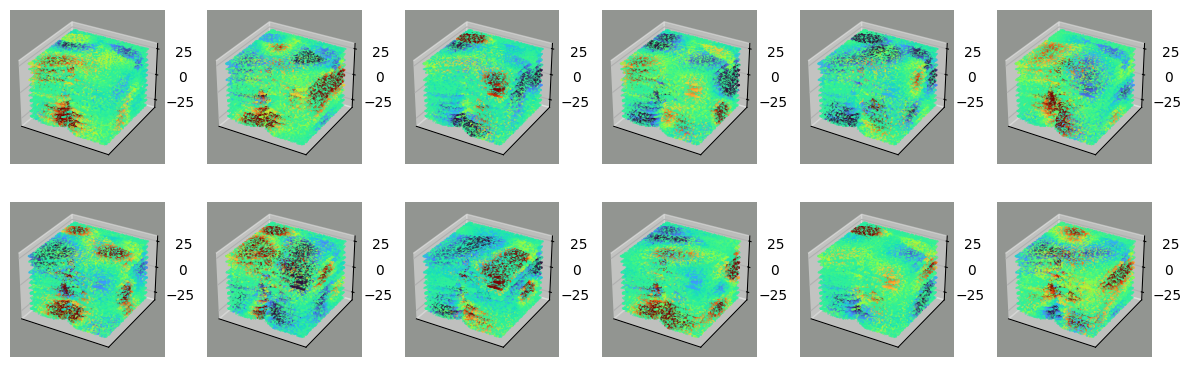

In [39]:

vmin=np.percentile(mean, 5)
vmax=np.percentile(mean, 95)
plot_factors(mean, X, moran_idx=None, ax=None, size=2, s=0.1, alpha=0.9, vmin=vmin, vmax=vmax)


In [40]:
vmax

np.float32(1.8002123)

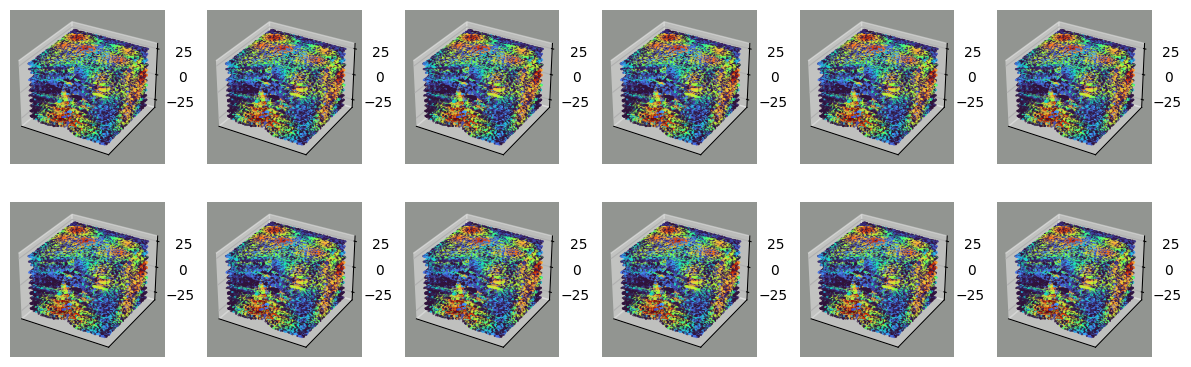

In [41]:
plot_factors(scale, X, moran_idx=None, ax=None, size=2, s=0.2, alpha=0.9)

In [42]:
def model_grads(model):
    model.prior.kernel.sigma.requires_grad = False
    model.prior.kernel.lengthscale.requires_grad = False
    model.prior.kernel.group_diff_param.requires_grad = False
    model.prior.Z.requires_grad=False
    model.prior.mu.requires_grad=True
    model.prior.Lu.requires_grad=True
    model.W.requires_grad=True

    
    
    model.V.requires_grad=False

In [43]:
model_grads(model)

In [44]:
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)

In [45]:
def train_batched_full_exp_with_tracking(optimizer, model, X, groupsX, y, device, steps=200, x_batch_size=1000, y_batch_size=1000, E=20, **kwargs):
    losses = []

    means = []
    scales = []
    idxs = []

    N = len(X)
    J = len(Y)

    full_knn_idx = model.prior.calculate_knn(X).clone()[:, :-1]

    for it in tqdm(range(steps)):

        # Sampling indices for minibatching
        idx = torch.multinomial(torch.ones(N), num_samples=x_batch_size, replacement=False)
        idy = torch.multinomial(torch.ones(J), num_samples=y_batch_size, replacement=False)

        X_batch = X[idx]
        y_batch = y[:, idx]
        groupsX_batch = groupsX[idx]

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        groupsX_batch = groupsX_batch.to(device)
        knn_idx = (full_knn_idx[idx]).to(device)
        
        model.prior.knn_idx = knn_idx

        optimizer.zero_grad()
        

        # pY, qF, qZ, _ = model.forward_batched(X_batch.squeeze(), idx=idx, groupsX=groupsX_batch, idy=idy)
        L1, qF, qZ, _ = model.forward_batched_train_separate(X_batch.squeeze(), y_batch, idx=idx, groupsX=groupsX_batch, idy=idy)
        
        L1 = L1.sum()
        # L1 = (L1 * N) / batch_size
        L2 = torch.sum(model.prior.kl_divergence_full(qZ, idx=idx))

        log_prob = L1 - L2
        loss = -log_prob

        loss.backward()
        optimizer.step()
        losses.append(loss.item())


        # Only track these every few steps to avoid memory overload
        if (it % 10) == 0:
            idxs.append(idx.detach().cpu().numpy())
            means.append(qF.mean.detach().cpu().numpy())  # or torch.exp(qZ.mean) if Poisson-like
            scales.append(qF.scale.detach().cpu().numpy())


        

        # Cleanup
        del qF, qZ, L1, L2, log_prob, loss
        model.prior.knn_idx = None

        del X_batch, y_batch, groupsX_batch, knn_idx

        with torch.no_grad():
            if device.type == 'cuda':
                torch.cuda.empty_cache()

        gc.collect()

    return losses, means, scales, idxs

In [46]:
def train_batched_with_tracking(optimizer, model, X, groupsX, y, device, steps=200, x_batch_size=1000, y_batch_size=1000, E=20, **kwargs):
    losses = []

    means = []
    scales = []
    idxs = []

    N = len(X)
    J = len(Y)

    full_knn_idx = model.prior.calculate_knn(X).clone()[:, :-1]

    for it in tqdm(range(steps)):

        # Sampling indices for minibatching
        idx = torch.multinomial(torch.ones(N), num_samples=x_batch_size, replacement=False)
        idy = torch.multinomial(torch.ones(J), num_samples=y_batch_size, replacement=False)

        X_batch = X[idx]
        y_batch = y[idy][:, idx]
        groupsX_batch = groupsX[idx]

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        groupsX_batch = groupsX_batch.to(device)
        knn_idx = (full_knn_idx[idx]).to(device)
        
        model.prior.knn_idx = knn_idx

        optimizer.zero_grad()
        

        # pY, qF, qZ, _ = model.forward_batched(X_batch.squeeze(), idx=idx, groupsX=groupsX_batch, idy=idy)
        pY, qF, qZ, _ = model.forward_batched_train(X_batch.squeeze(), idx=idx, groupsX=groupsX_batch, idy=idy)
        


        logpY = y_batch*torch.log(pY.rate) - pY.rate

        L1 = (logpY).mean(axis=0).sum()
        # L1 = (L1 * N) / batch_size
        L2 = torch.sum(model.prior.kl_divergence_full(qZ, idx=idx))

        log_prob = L1 - L2
        loss = -log_prob

        loss.backward()
        optimizer.step()
        losses.append(loss.item())


        # Only track these every few steps to avoid memory overload
        if (it % 10) == 0:
            idxs.append(idx.detach().cpu().numpy())
            means.append(qF.mean.detach().cpu().numpy())  # or torch.exp(qZ.mean) if Poisson-like
            scales.append(qF.scale.detach().cpu().numpy())


        

        # Cleanup
        del pY, qF, qZ, logpY, L1, L2, log_prob, loss
        model.prior.knn_idx = None

        del X_batch, y_batch, groupsX_batch, knn_idx

        with torch.no_grad():
            if device.type == 'cuda':
                torch.cuda.empty_cache()

        gc.collect()

    return losses, means, scales, idxs

In [47]:
model.prior.jitter=1e-5

In [48]:
steps = 15*4000
model.to(device)

NSF2(
  (prior): MGGP_VNNGP(
    (kernel): batched_MGGP_Matern32()
  )
)

In [49]:
model.prior.kernel.lengthscale

Parameter containing:
tensor(5., device='cuda:0')

In [ ]:
losses, means, scales, idxs = train_batched_full_exp_with_tracking(
    optimizer=optimizer,
    model=model,
    X=X,  # original input matrix
    groupsX=groupsX,  # group/category IDs for each sample
    y=Y,  # your actual target
    device=device,
    steps=steps,
    x_batch_size=15000,
    y_batch_size=D,
    E=1
)

  0%|          | 0/60000 [00:00<?, ?it/s]

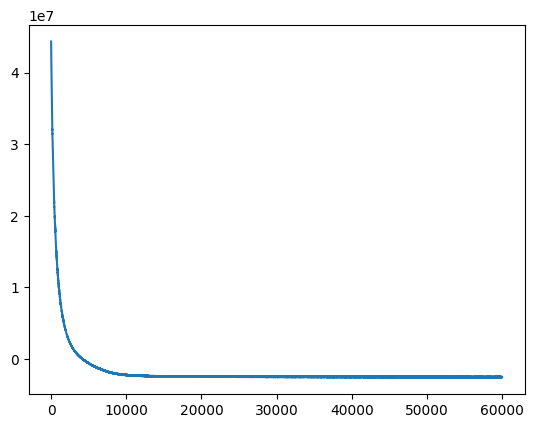

In [51]:
plt.plot(losses)

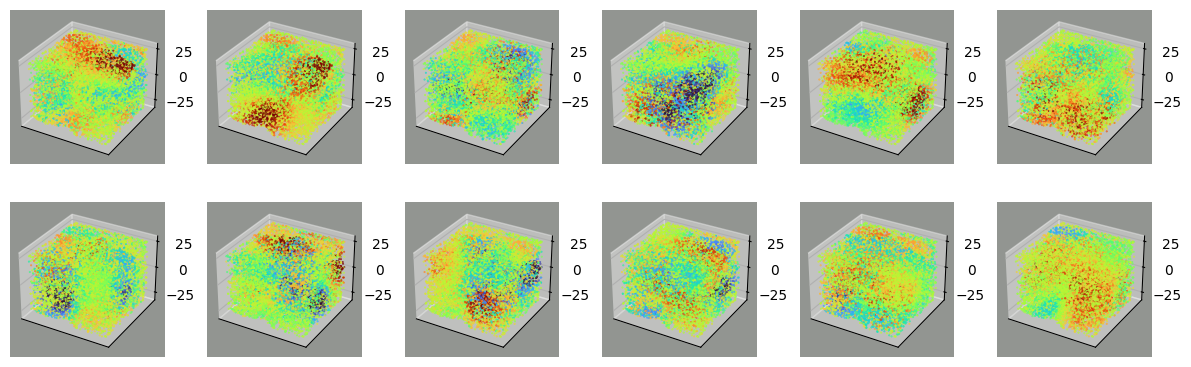

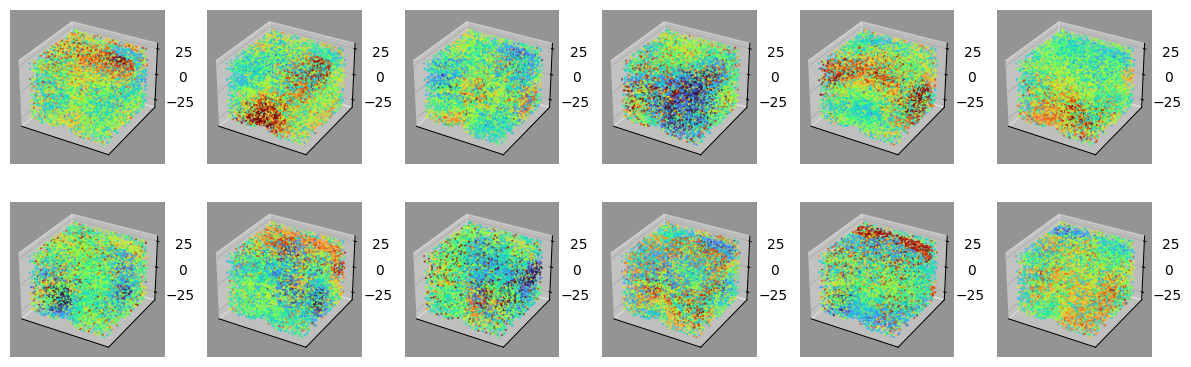

In [51]:
plot_factors(means[0], X[idxs[0]], moran_idx=None, ax=None, size=2, s=0.2, alpha=0.9)
plot_factors(means[-1], X[idxs[-1]], moran_idx=None, ax=None, size=2, s=0.2, alpha=0.9)

In [54]:
torch.save(model.state_dict(), '../models/merfish_squidpy_mggp_matern32_umap_init.pth')

In [53]:
model.prior.kernel.lengthscale

Parameter containing:
tensor(10., device='cuda:0')

In [54]:
def get_groupwise_factors(model, X_test, codes, L=12, vmin=0, vmax=2.0):
    model.cpu()
    model.eval()

    with torch.no_grad():
        group_ids = codes.unique().tolist()
        results = []

        knn_idx = model.prior.calculate_knn(X_test)
        model.prior.knn_idx = knn_idx[:, :-1]

        for group_index in tqdm(group_ids):
            group_mask = (groupsX == group_index)
            groupsX_test = torch.full_like(groupsX, fill_value=group_index)

            qF_test, _, _ = model.prior(X_test, groupsX=groupsX_test)
            factors_test = torch.exp(qF_test.mean).cpu().numpy()

            del qF_test

            results.append({
                'group_index': group_index,
                'group_mask': group_mask.cpu().numpy(),
                'factors': factors_test
            })

        return results


In [55]:
def plot_groupwise_factors(results, X_test, categories, mean, L=12, size=2, s=0.2, alpha=0.9, vmin=0, vmax=2.0):
    cols = [f"Factor {i}" for i in range(1, L + 1)]
    nrows = len(results)

    fig, axes = plt.subplots(nrows=nrows+1, ncols=L + 1,
                             figsize=(size * (L + 1), size * (nrows+1)),
                             squeeze=False)  # ensure axes is 2D even if nrows=1

    axes[0, 0].axis("off")

    for j in range(L):
        axes[0, j + 1].scatter(X_test[:, 0], X_test[:, 1],
                               c=mean[j],
                               vmin=vmin, vmax=vmax,
                               alpha=alpha, s=s, cmap='turbo')
        axes[0, j + 1].invert_yaxis()
        axes[0, j + 1].set(xticks=[], yticks=[])
        axes[0, j + 1].set_title(cols[j], fontsize=10)

    
    for i, result in enumerate(tqdm(results)):

        row_plot_idx = i + 1  # shift down for mean
        
        group_index = result['group_index']
        group_mask = result['group_mask']
        factors_test = result['factors']
        row_name = categories[group_index]
        display_name = ' '.join(row_name.split('_')[:2])

        # Grayscale overlay for cell identity
        cell_fake_factor = np.full_like(factors_test[0], fill_value=0.0)
        cell_fake_factor[group_mask] = 1.0

        axes[row_plot_idx, 0].scatter(X_test[:, 0], X_test[:, 1],
                           c=cell_fake_factor,
                           vmin=0.0, vmax=1.0,
                           alpha=alpha, s=s, cmap='gray')
        axes[row_plot_idx, 0].invert_yaxis()
        axes[row_plot_idx, 0].set(xticks=[], yticks=[])
        axes[row_plot_idx, 0].set_ylabel(display_name, rotation=0, fontsize=10, labelpad=50)

        for j in range(L):
            axes[row_plot_idx, j + 1].scatter(X_test[:, 0], X_test[:, 1],
                                   c=factors_test[j],
                                   vmin=vmin, vmax=vmax,
                                   alpha=alpha, s=s, cmap='turbo')
            axes[row_plot_idx, j + 1].invert_yaxis()
            axes[row_plot_idx, j + 1].set(xticks=[], yticks=[])

    fig.tight_layout()
    plt.show()


In [56]:
results = get_groupwise_factors(model, X, groupsX, L=12)

  0%|          | 0/16 [00:00<?, ?it/s]

In [57]:
adata.obs.Cell_Type.values.categories.to_list()

AttributeError: 'DataFrame' object has no attribute 'Cell_Type'

In [ ]:
batch =0
batch_size=9
plot_groupwise_factors(results[batch*batch_size:(batch+1)*batch_size], X, adata.obs.Cell_Type.values.categories.to_list(), mean, L=12, vmax=5.0)

In [91]:
X

tensor([[-1438.5139, -2973.2947],
        [-1414.7710, -2968.4895],
        [-1423.5206, -2962.3540],
        ...,
        [ 1568.9739, -1375.8602],
        [ 1559.7289, -1720.8103],
        [  249.4674, -1192.3524]])